# Las raíces estructurales de la pobreza territorial en México
## Censo de Población y Vivienda 2020 — INEGI

**Narrativa central:** *"En México no se puede hablar de pobreza sin hablar de dónde naciste."*

Este notebook explora **por qué** la pobreza persiste en ciertos territorios,
usando datos del Censo 2020 (INEGI) sobre educación, vivienda, salud, etnicidad
y estructura económica a nivel estatal.

**Pregunta que responde:** ¿Qué factores estructurales explican la brecha territorial de pobreza?

**ODS vinculados:** ODS 1 (Fin de la Pobreza) · ODS 10 (Reducción de las Desigualdades)


## 1. Configuración

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import sys, os

sys.path.insert(0, str(Path(".") / "scripts"))
from parse_censo import extraer_valores_estado, REGIONES, ESTADOS_CORTOS

DARK_BG = "#1a1a2e"
ACCENT  = "#e94560"
GOLD    = "#f5a623"
TEAL    = "#0f9b8e"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "figure.dpi": 120,
    "figure.figsize": (14, 8),
})

IMG_DIR = Path("imagenes")
IMG_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("datos/censo2020")

print("Archivos disponibles:")
for f in sorted(DATA_DIR.glob("*.xlsx")):
    print(f"  {f.name} ({f.stat().st_size // 1024} KB)")


Archivos disponibles:
  cpv2020_a_alimentacion.xlsx (137 KB)
  cpv2020_a_discapacidad.xlsx (986 KB)
  cpv2020_a_economia.xlsx (7154 KB)
  cpv2020_a_educacion.xlsx (231 KB)
  cpv2020_a_etnicidad.xlsx (238 KB)
  cpv2020_a_ingresos.xlsx (116 KB)
  cpv2020_a_migracion.xlsx (396 KB)
  cpv2020_a_poblacion.xlsx (682 KB)
  cpv2020_a_salud.xlsx (989 KB)
  cpv2020_a_vivienda.xlsx (1045 KB)


## 2. Extracción de indicadores clave por estado

Parseamos los tabulados ampliados del Censo 2020 para construir un dataframe
consolidado con indicadores estructurales por entidad federativa.


In [6]:
# --- EDUCACIÓN (sheet 04): educación superior por estado ---
df_edu = extraer_valores_estado(
    DATA_DIR / "cpv2020_a_educacion.xlsx", "04",
    col_indices=[3],
    col_names=["pob_educ_superior"]
)
df_edu = df_edu[df_edu["estado"] != "Estados Unidos Mexicanos"]
print(f"Educación: {len(df_edu)} estados")

# --- ETNICIDAD (sheet 02): % población indígena por estado ---
# col 2 = "Condición de habla indígena", filtrar por "Total"
df_etnia = extraer_valores_estado(
    DATA_DIR / "cpv2020_a_etnicidad.xlsx", "02",
    col_indices=[4, 5],
    col_names=["pob_3mas", "pct_indigena"],
    sexo_col=1, estimador_col=3,
    extra_filter_col=2, extra_filter_val="Total"
)
df_etnia = df_etnia[df_etnia["estado"] != "Estados Unidos Mexicanos"]
print(f"Etnicidad: {len(df_etnia)} estados")

# --- SALUD (sheet 02): % uso de servicios de salud por estado ---
# col 2 = "Grupos de edad", filtrar por "Total"
df_salud = extraer_valores_estado(
    DATA_DIR / "cpv2020_a_salud.xlsx", "02",
    col_indices=[4, 5, 6],
    col_names=["pob_total_salud", "pct_uso_salud", "pct_imss"],
    sexo_col=1, estimador_col=3,
    extra_filter_col=2, extra_filter_val="Total"
)
df_salud = df_salud[df_salud["estado"] != "Estados Unidos Mexicanos"]
print(f"Salud: {len(df_salud)} estados")

# --- ALIMENTACIÓN (sheet 02): inseguridad alimentaria por estado ---
# col 1 = Sexo de persona referencia, col 2 = Estimador
# col 4 = % SI tiene limitación de acceso a alimentos
df_alim = extraer_valores_estado(
    DATA_DIR / "cpv2020_a_alimentacion.xlsx", "02",
    col_indices=[3, 4],
    col_names=["hogares_total", "pct_inseg_alimentaria"],
    sexo_col=1, estimador_col=2
)
df_alim = df_alim[df_alim["estado"] != "Estados Unidos Mexicanos"]
print(f"Alimentación: {len(df_alim)} estados")

print("\nExtracción completada.")


Educación: 32 estados
Etnicidad: 32 estados
Salud: 32 estados
Alimentación: 32 estados

Extracción completada.


## 3. Construcción del dataset consolidado

Unimos los indicadores del Censo 2020 con datos de pobreza multidimensional
para cruzar estructura censal con pobreza.


In [7]:
# Intentar cargar datos de pobreza de Jhoshua
PM_PATH = Path("..") / "Posibles Datos Jhoshua" / "datos" / "pobreza_multidimensional" / "pm_ef_2024.xlsx"

if PM_PATH.exists():
    import openpyxl
    wb = openpyxl.load_workbook(PM_PATH, read_only=True)
    records_pm = []
    # Normalize long PM names → short census names
    PM_NAME_MAP = {
        "Ciudad de México": "CDMX",
        "México": "Estado de México",
        "Veracruz de Ignacio de la Llave": "Veracruz",
        "Coahuila de Zaragoza": "Coahuila",
        "Michoacán de Ocampo": "Michoacán",
    }
    SKIP_SHEETS = {"Índice", "EUM"}
    for sheet_name in wb.sheetnames:
        if sheet_name in SKIP_SHEETS or sheet_name.strip() in SKIP_SHEETS:
            continue
        ws = wb[sheet_name]
        rows = list(ws.iter_rows(values_only=True))
        if len(rows) < 10:
            continue
        # R4 (index 3) contains the full state name
        estado_name = str(rows[3][0]).strip() if rows[3][0] else sheet_name
        estado_name = PM_NAME_MAP.get(estado_name, estado_name)
        # R10 (index 9): "Población en situación de pobreza"
        # Structure: cols 4-8 = thousands of persons (2016-2024)
        #            cols 10-14 = percentages (2016-2024)  ← col 14 = % 2024
        r10 = rows[9]
        pct_2024 = r10[14] if len(r10) > 14 else None
        if pct_2024 is not None and isinstance(pct_2024, (int, float)):
            records_pm.append({"estado_pm": estado_name, "pct_pobreza_2024": float(pct_2024)})
    wb.close()
    df_pm = pd.DataFrame(records_pm)
    print(f"PM cargada: {len(df_pm)} estados desde Jhoshua")
else:
    print(f"PM no encontrada en {PM_PATH}, usando referencia CONEVAL")
    df_pm = pd.DataFrame({
        "estado_pm": ["Chiapas","Guerrero","Oaxaca","Puebla","Veracruz",
                      "Tabasco","Tlaxcala","Hidalgo","Michoacán","Campeche",
                      "San Luis Potosí","Zacatecas","Morelos","Durango","Guanajuato",
                      "Yucatán","Quintana Roo","Estado de México","Nayarit","Sinaloa",
                      "Tamaulipas","Colima","Jalisco","Sonora","Chihuahua",
                      "Querétaro","Aguascalientes","Coahuila","CDMX",
                      "Baja California Sur","Nuevo León","Baja California"],
        "pct_pobreza_2024": [67.4,60.4,58.4,53.0,52.4,48.2,47.8,45.2,43.4,42.8,
                            41.2,40.8,39.6,38.4,37.8,37.2,36.4,35.8,35.2,30.4,
                            29.8,29.2,28.4,26.8,25.2,24.8,23.4,22.8,21.4,
                            18.2,16.4,15.8]
    })


PM cargada: 32 estados desde Jhoshua


In [8]:
# Consolidar
REGION_COLORS = {"Norte": TEAL, "Centro": GOLD, "Sur": ACCENT, "CDMX": "#7b68ee"}

df = df_edu[["estado", "region", "pob_educ_superior"]].copy()
df = df.merge(df_etnia[["estado", "pct_indigena"]], on="estado", how="left")
df = df.merge(df_salud[["estado", "pct_uso_salud"]], on="estado", how="left")

if len(df_alim) > 0 and "pct_inseg_alimentaria" in df_alim.columns:
    df = df.merge(df_alim[["estado", "pct_inseg_alimentaria"]], on="estado", how="left")

df = df.merge(df_pm, left_on="estado", right_on="estado_pm", how="left")
if "estado_pm" in df.columns:
    df = df.drop(columns=["estado_pm"])

df["color"] = df["region"].map(REGION_COLORS)

print(f"Dataset consolidado: {len(df)} estados, {len(df.columns)} columnas")
print(df.sort_values("pct_pobreza_2024", ascending=False).head(10).to_string(index=False))


Dataset consolidado: 32 estados, 8 columnas
   estado region  pob_educ_superior  pct_indigena  pct_uso_salud  pct_inseg_alimentaria  pct_pobreza_2024   color
  Chiapas    Sur           485257.0     36.788107      96.557828              11.685745         65.968212 #e94560
 Guerrero    Sur           370611.0     33.139736      97.920268              14.552084         58.061089 #e94560
   Oaxaca    Sur           405003.0     69.180846      97.623518              15.890900         51.613765 #e94560
 Veracruz    Sur          1056599.0     26.901285      98.153578              11.193560         44.501788 #e94560
   Puebla Centro           908745.0     33.222989      98.022137               8.662479         43.442769 #f5a623
 Tlaxcala Centro           191895.0     16.457306      96.629682               9.335042         40.805193 #f5a623
 Campeche    Sur           155090.0     47.258104      96.647059              11.688188         36.749035 #e94560
Zacatecas  Norte           202851.0      4.8

## 4. Educación y pobreza

**Hipótesis:** Los estados con menor acceso a educación superior tienen mayor pobreza.
Si nacer en un estado determina tu acceso a educación, determina tu probabilidad de ser pobre.


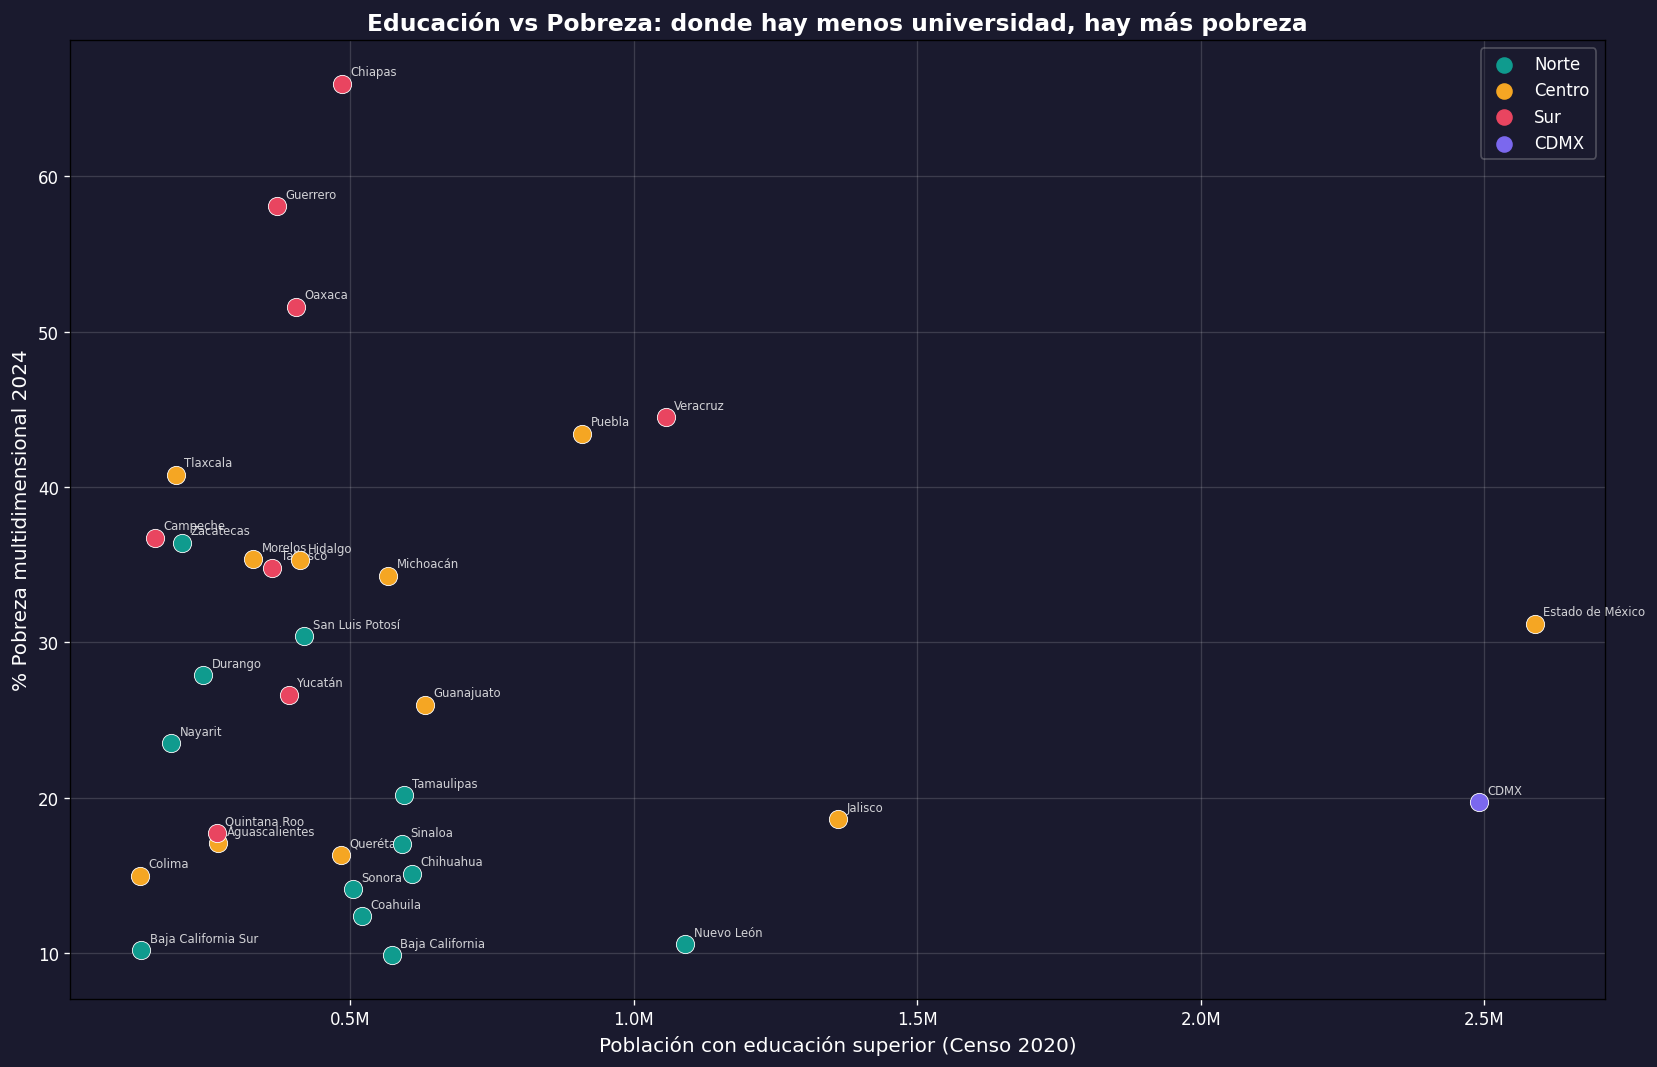

In [9]:
fig, ax = plt.subplots(figsize=(14, 9))

valid = df.dropna(subset=["pob_educ_superior", "pct_pobreza_2024"])

for _, row in valid.iterrows():
    ax.scatter(row["pob_educ_superior"], row["pct_pobreza_2024"],
              c=row["color"], s=120, zorder=5, edgecolors="white", linewidth=0.5)
    ax.annotate(row["estado"], (row["pob_educ_superior"], row["pct_pobreza_2024"]),
               fontsize=7, color="white", alpha=0.8,
               xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Población con educación superior (Censo 2020)", fontsize=12)
ax.set_ylabel("% Pobreza multidimensional 2024", fontsize=12)
ax.set_title("Educación vs Pobreza: donde hay menos universidad, hay más pobreza",
            fontsize=14, fontweight="bold", color="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for reg, col in REGION_COLORS.items():
    ax.scatter([], [], c=col, s=80, label=reg)
ax.legend(loc="upper right", fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.15, color="white")

plt.tight_layout()
plt.savefig(IMG_DIR / "isr_educacion_vs_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Etnicidad y pobreza

**Hipótesis:** La pobreza en México tiene un componente étnico estructural.
Los estados con mayor población indígena concentran más pobreza — no por casualidad,
sino por siglos de exclusión de servicios, infraestructura y oportunidades.


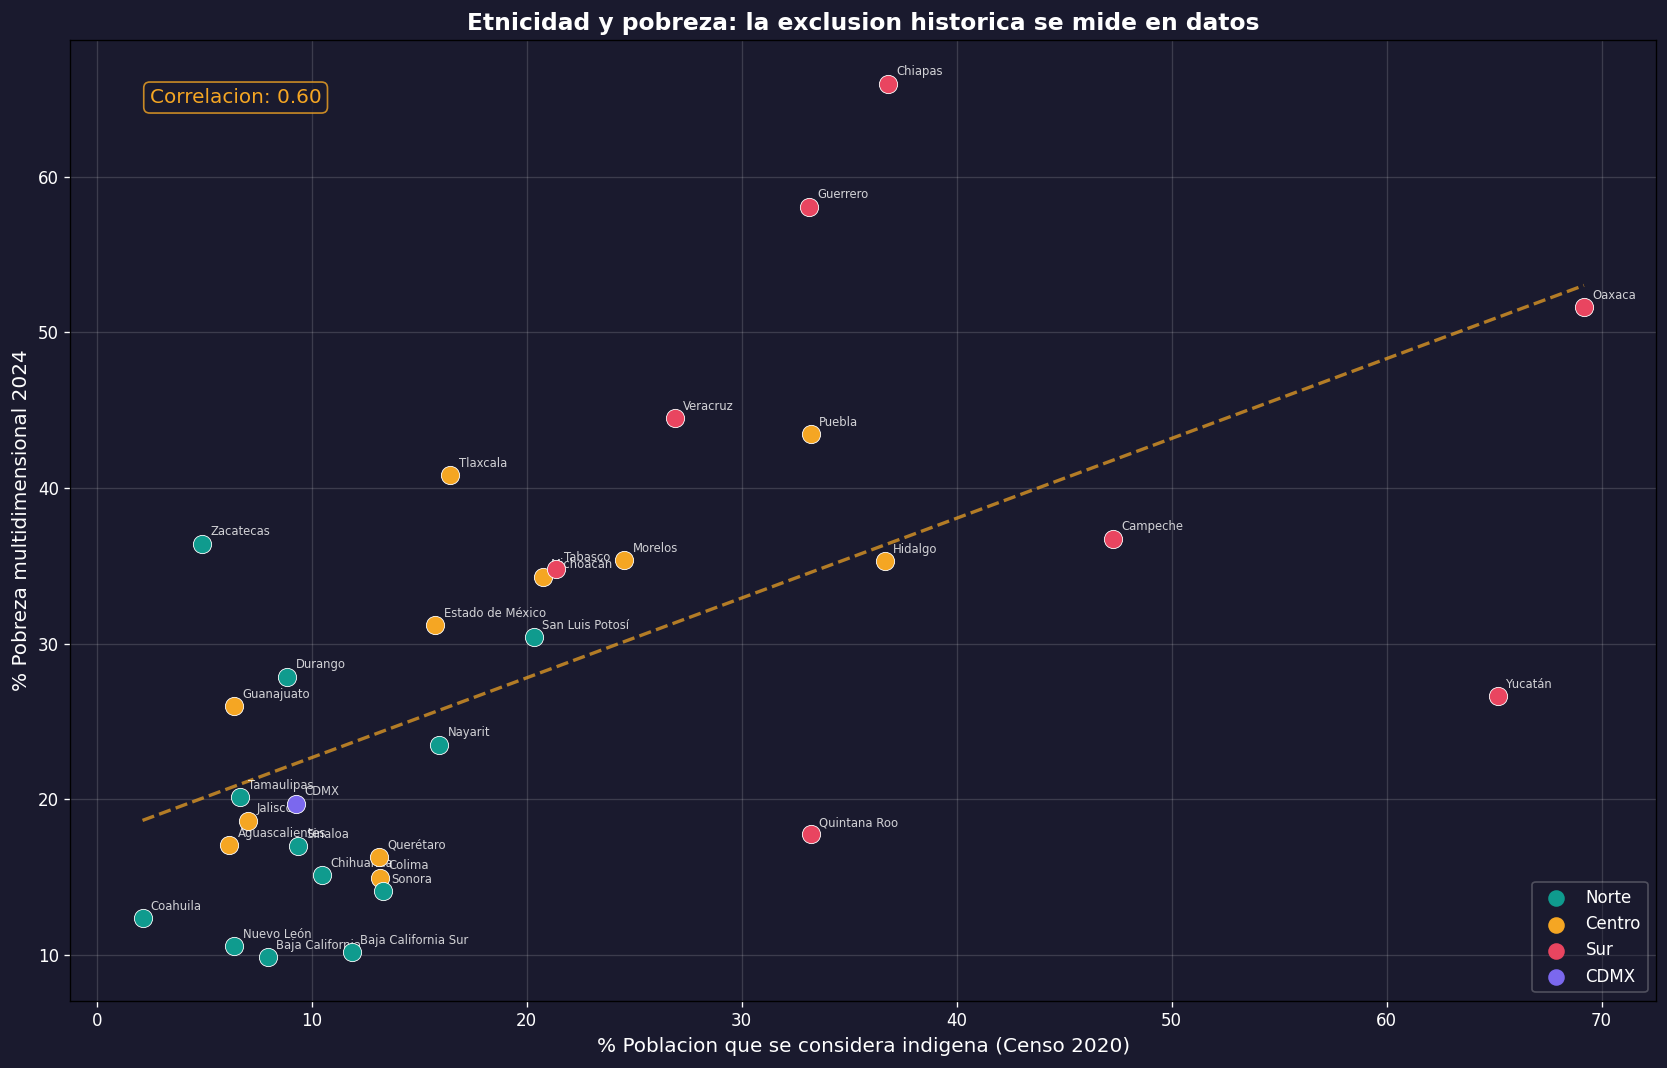

In [10]:
fig, ax = plt.subplots(figsize=(14, 9))

valid = df.dropna(subset=["pct_indigena", "pct_pobreza_2024"])

for _, row in valid.iterrows():
    ax.scatter(row["pct_indigena"], row["pct_pobreza_2024"],
              c=row["color"], s=120, zorder=5, edgecolors="white", linewidth=0.5)
    ax.annotate(row["estado"], (row["pct_indigena"], row["pct_pobreza_2024"]),
               fontsize=7, color="white", alpha=0.8,
               xytext=(5, 5), textcoords="offset points")

# Línea de tendencia
z = np.polyfit(valid["pct_indigena"], valid["pct_pobreza_2024"], 1)
p = np.poly1d(z)
x_line = np.linspace(valid["pct_indigena"].min(), valid["pct_indigena"].max(), 100)
ax.plot(x_line, p(x_line), "--", color=GOLD, alpha=0.7, linewidth=2)

corr = valid["pct_indigena"].corr(valid["pct_pobreza_2024"])
ax.text(0.05, 0.95, f"Correlacion: {corr:.2f}",
       transform=ax.transAxes, fontsize=12, color=GOLD,
       verticalalignment="top",
       bbox=dict(boxstyle="round", facecolor=DARK_BG, edgecolor=GOLD, alpha=0.8))

ax.set_xlabel("% Poblacion que se considera indigena (Censo 2020)", fontsize=12)
ax.set_ylabel("% Pobreza multidimensional 2024", fontsize=12)
ax.set_title("Etnicidad y pobreza: la exclusion historica se mide en datos",
            fontsize=14, fontweight="bold", color="white")

for reg, col in REGION_COLORS.items():
    ax.scatter([], [], c=col, s=80, label=reg)
ax.legend(loc="lower right", fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.15, color="white")

plt.tight_layout()
plt.savefig(IMG_DIR / "isr_etnicidad_vs_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Ranking de estados: pobreza, etnicidad y educación

Vista consolidada de cómo se distribuyen los factores estructurales
entre los estados más pobres y los menos pobres.


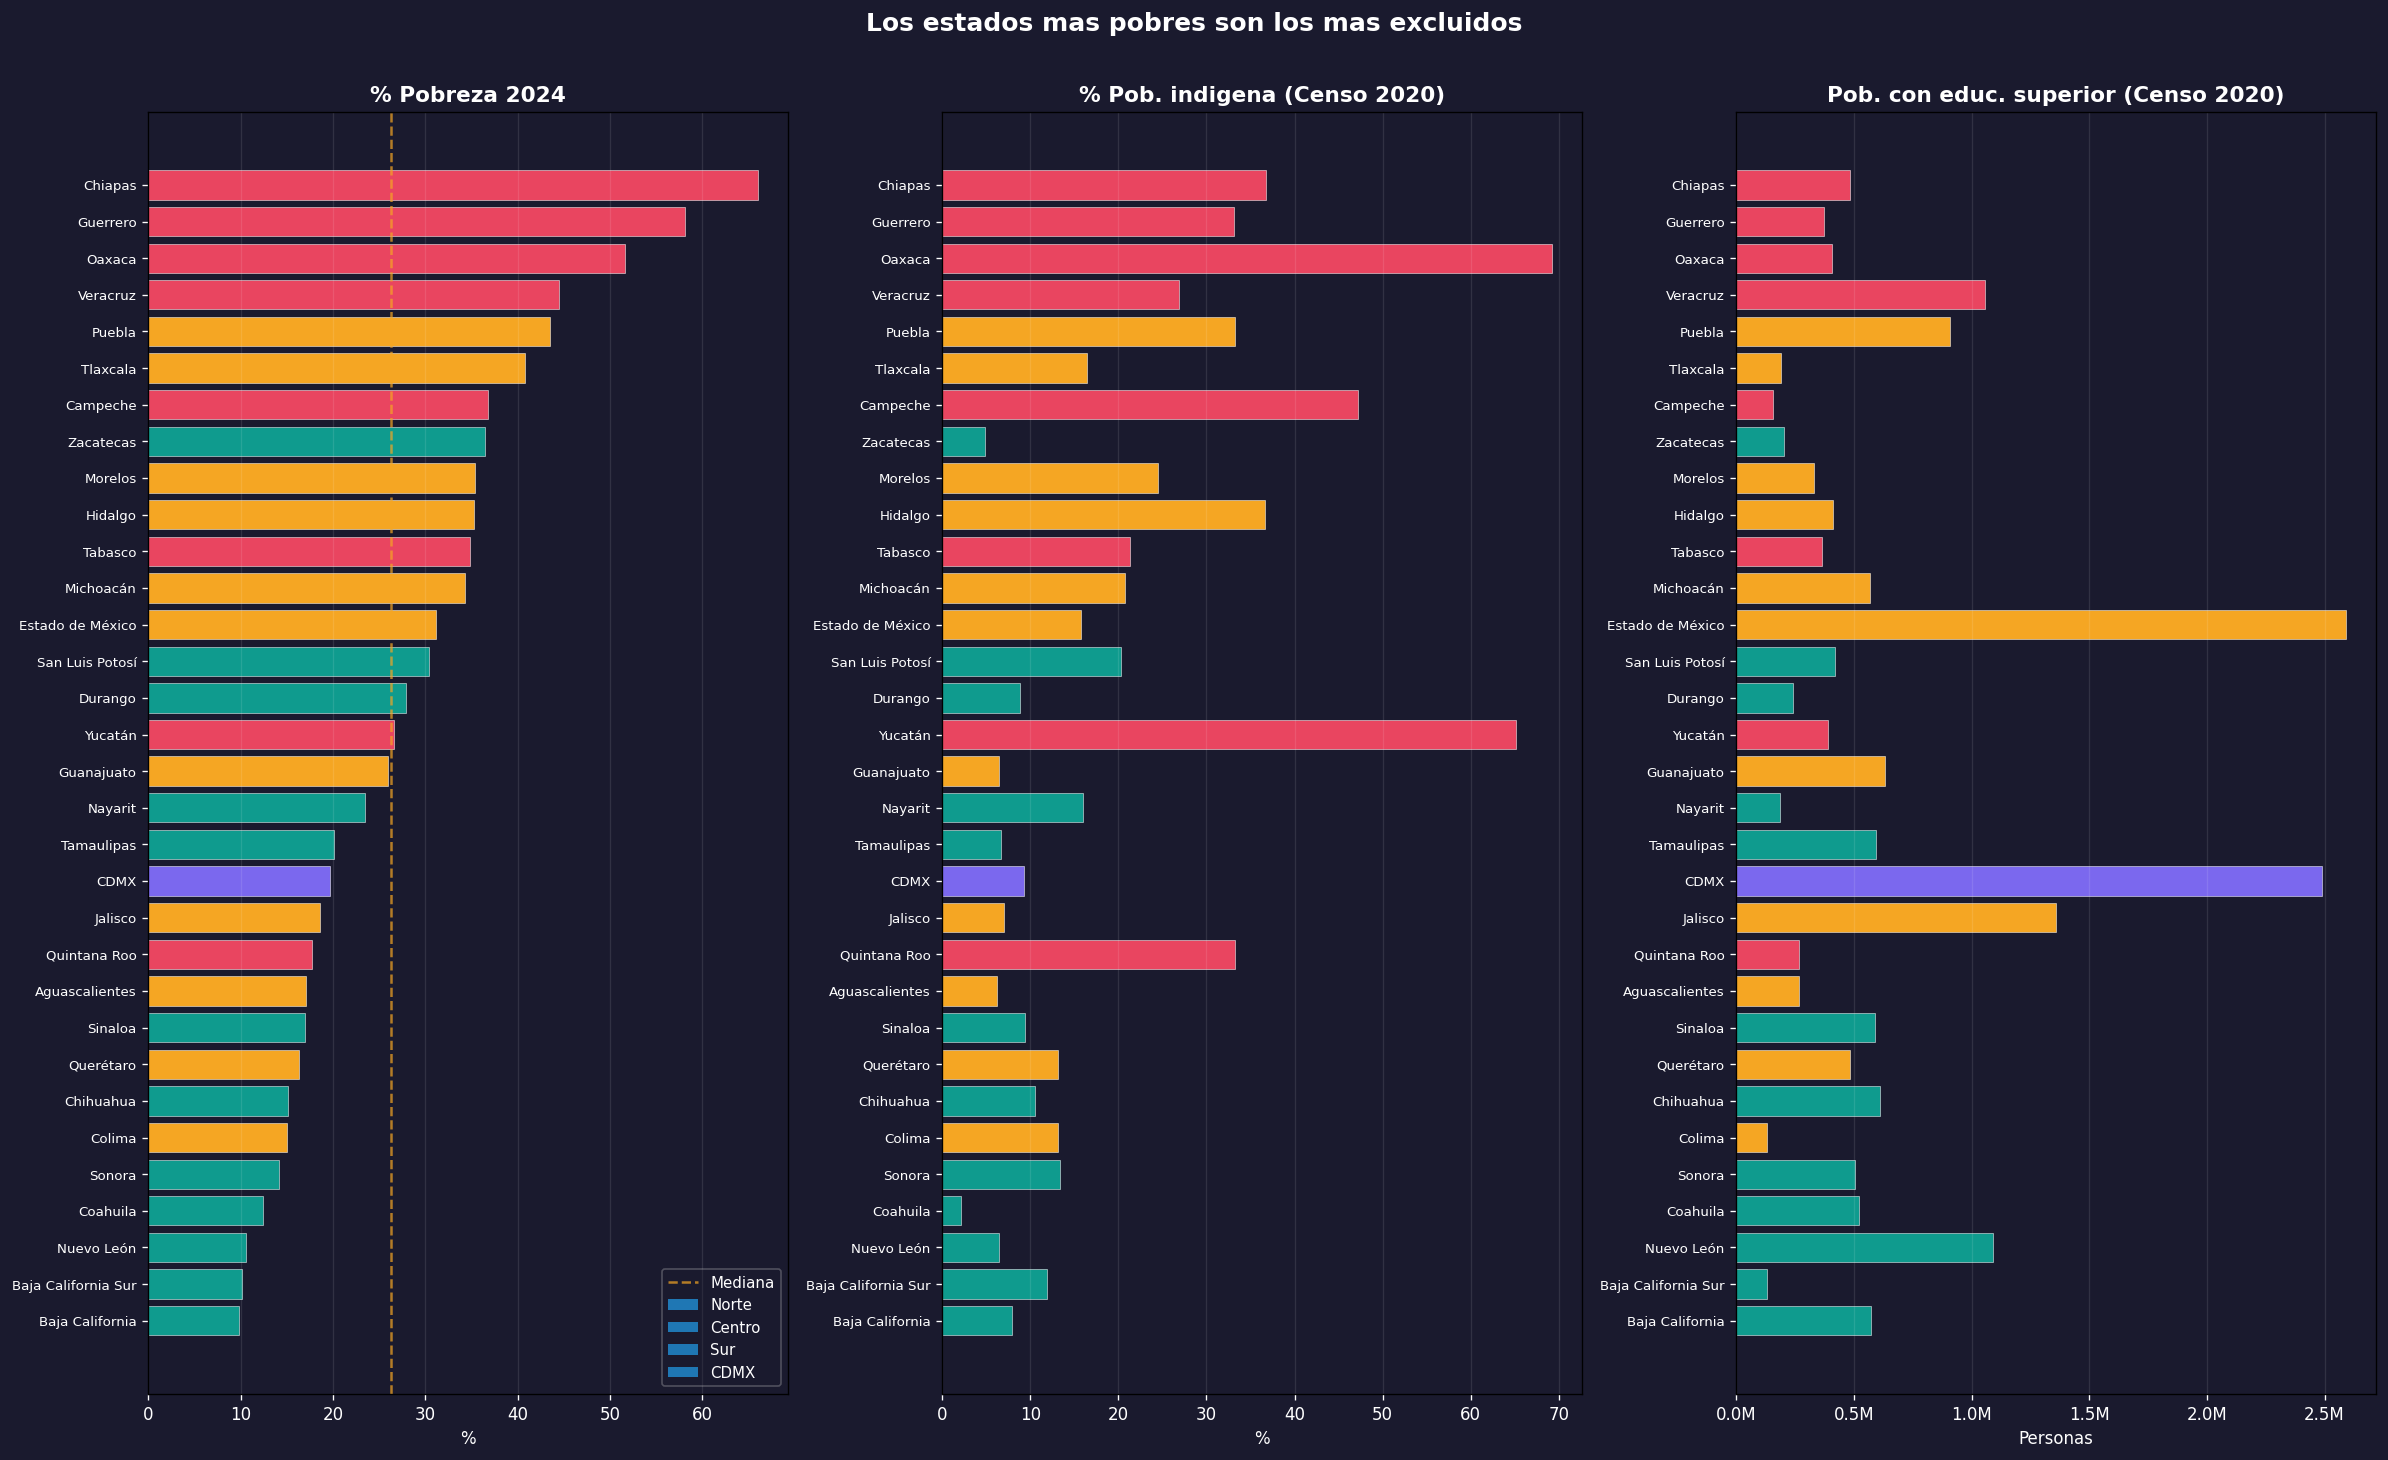

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 12))

df_sorted = df.sort_values("pct_pobreza_2024", ascending=True)
colors_bar = [REGION_COLORS.get(r, "gray") for r in df_sorted["region"]]

# Panel 1: % Pobreza
axes[0].barh(df_sorted["estado"], df_sorted["pct_pobreza_2024"],
            color=colors_bar, edgecolor="white", linewidth=0.3)
axes[0].set_title("% Pobreza 2024", fontsize=13, fontweight="bold", color="white")
axes[0].set_xlabel("%", color="white")
axes[0].axvline(df_sorted["pct_pobreza_2024"].median(), color=GOLD,
               linestyle="--", alpha=0.7, label="Mediana")

# Panel 2: % Población indígena
if "pct_indigena" in df_sorted.columns:
    axes[1].barh(df_sorted["estado"], df_sorted["pct_indigena"].fillna(0),
                color=colors_bar, edgecolor="white", linewidth=0.3)
    axes[1].set_title("% Pob. indigena (Censo 2020)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("%")

# Panel 3: Educación superior
axes[2].barh(df_sorted["estado"], df_sorted["pob_educ_superior"].fillna(0),
            color=colors_bar, edgecolor="white", linewidth=0.3)
axes[2].set_title("Pob. con educ. superior (Censo 2020)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Personas")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, alpha=0.1, color="white", axis="x")

for reg, col in REGION_COLORS.items():
    axes[0].barh([], [], color=col, label=reg)
axes[0].legend(loc="lower right", fontsize=9, framealpha=0.3)

plt.suptitle("Los estados mas pobres son los mas excluidos",
            fontsize=15, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "isr_ranking_tripartito.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Comparación regional: heatmap y distribución

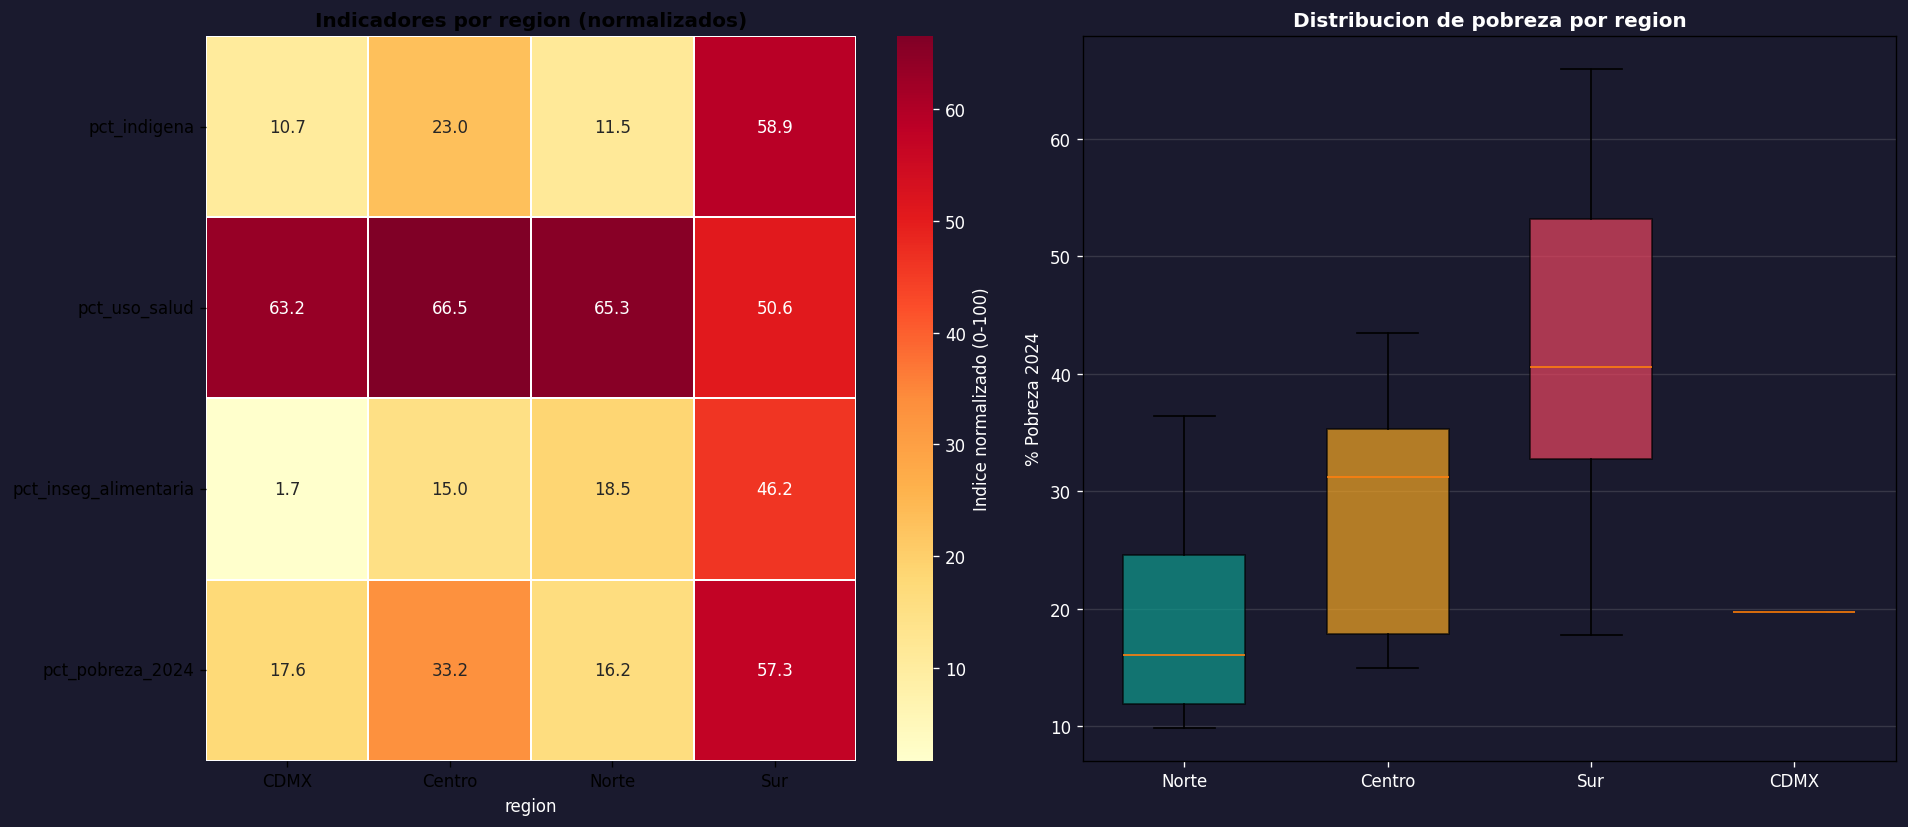

In [12]:
cols_radar = [c for c in ["pct_indigena", "pct_uso_salud", "pct_inseg_alimentaria", "pct_pobreza_2024"]
             if c in df.columns and df[c].notna().sum() > 5]

if len(cols_radar) >= 2:
    df_norm = df.copy()
    for col in cols_radar:
        mn, mx = df_norm[col].min(), df_norm[col].max()
        if mx > mn:
            df_norm[col + "_norm"] = (df_norm[col] - mn) / (mx - mn) * 100

    norm_cols = [c + "_norm" for c in cols_radar if c + "_norm" in df_norm.columns]
    region_means = df_norm.groupby("region")[norm_cols].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(region_means.T, annot=True, fmt=".1f", cmap="YlOrRd",
               ax=axes[0], linewidths=1,
               cbar_kws={"label": "Indice normalizado (0-100)"},
               xticklabels=region_means.index)
    axes[0].set_title("Indicadores por region (normalizados)",
                     fontsize=12, fontweight="bold", color="black")
    axes[0].set_yticklabels([c.replace("_norm", "") for c in norm_cols], rotation=0)
    axes[0].set_facecolor("white")
    axes[0].tick_params(colors="black")

    bp_data = [df[df["region"] == r]["pct_pobreza_2024"].dropna().values
              for r in ["Norte", "Centro", "Sur", "CDMX"] if r in df["region"].values]
    bp_labels = [r for r in ["Norte", "Centro", "Sur", "CDMX"] if r in df["region"].values]
    bp = axes[1].boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.6)
    for patch, label in zip(bp["boxes"], bp_labels):
        patch.set_facecolor(REGION_COLORS.get(label, "gray"))
        patch.set_alpha(0.7)
    axes[1].set_title("Distribucion de pobreza por region", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("% Pobreza 2024")
    axes[1].grid(True, alpha=0.2, axis="y")

    plt.tight_layout()
    plt.savefig(IMG_DIR / "isr_regiones_estructura.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8. Hallazgos clave

In [13]:
print("=" * 65)
print("HALLAZGOS: RAICES ESTRUCTURALES DE LA POBREZA TERRITORIAL")
print("=" * 65)

top5 = df.nlargest(5, "pct_pobreza_2024")
bot5 = df.nsmallest(5, "pct_pobreza_2024")

print("\n1. LOS 5 ESTADOS MAS POBRES:")
for _, r in top5.iterrows():
    ind = f", Indigena: {r['pct_indigena']:.1f}%" if pd.notna(r.get('pct_indigena')) else ""
    print(f"   {r['estado']}: {r['pct_pobreza_2024']:.1f}% pobreza{ind}")

print("\n2. LOS 5 ESTADOS MENOS POBRES:")
for _, r in bot5.iterrows():
    ind = f", Indigena: {r['pct_indigena']:.1f}%" if pd.notna(r.get('pct_indigena')) else ""
    print(f"   {r['estado']}: {r['pct_pobreza_2024']:.1f}% pobreza{ind}")

if "pct_indigena" in df.columns:
    corr = df["pct_indigena"].corr(df["pct_pobreza_2024"])
    print(f"\n3. CORRELACION etnicidad-pobreza: {corr:.3f}")

norte_p = df[df["region"] == "Norte"]["pct_pobreza_2024"].mean()
sur_p = df[df["region"] == "Sur"]["pct_pobreza_2024"].mean()
print(f"\n4. BRECHA REGIONAL:")
print(f"   Norte promedio: {norte_p:.1f}%")
print(f"   Sur promedio:   {sur_p:.1f}%")
print(f"   Diferencia:     {sur_p - norte_p:.1f} puntos")

print("\n" + "=" * 65)
print("CONCLUSION: La pobreza en Mexico no es aleatoria.")
print("Tiene raices en educacion, etnicidad y acceso a servicios.")
print("Nacer en el sur determina tus probabilidades.")
print("=" * 65)


HALLAZGOS: RAICES ESTRUCTURALES DE LA POBREZA TERRITORIAL

1. LOS 5 ESTADOS MAS POBRES:
   Chiapas: 66.0% pobreza, Indigena: 36.8%
   Guerrero: 58.1% pobreza, Indigena: 33.1%
   Oaxaca: 51.6% pobreza, Indigena: 69.2%
   Veracruz: 44.5% pobreza, Indigena: 26.9%
   Puebla: 43.4% pobreza, Indigena: 33.2%

2. LOS 5 ESTADOS MENOS POBRES:
   Baja California: 9.9% pobreza, Indigena: 8.0%
   Baja California Sur: 10.2% pobreza, Indigena: 11.9%
   Nuevo León: 10.6% pobreza, Indigena: 6.4%
   Coahuila: 12.4% pobreza, Indigena: 2.1%
   Sonora: 14.1% pobreza, Indigena: 13.3%

3. CORRELACION etnicidad-pobreza: 0.596

4. BRECHA REGIONAL:
   Norte promedio: 19.0%
   Sur promedio:   42.0%
   Diferencia:     23.0 puntos

CONCLUSION: La pobreza en Mexico no es aleatoria.
Tiene raices en educacion, etnicidad y acceso a servicios.
Nacer en el sur determina tus probabilidades.


## Fuentes de datos

| Fuente | Institucion | Acceso |
|--------|-------------|--------|
| Censo de Poblacion y Vivienda 2020 | INEGI | [inegi.org.mx/programas/ccpv/2020](https://www.inegi.org.mx/programas/ccpv/2020/) |
| Pobreza Multidimensional 2024 | INEGI/CONEVAL | [inegi.org.mx/desarrollosocial/pm](https://www.inegi.org.mx/desarrollosocial/pm/) |

**Archivos utilizados:**
- `cpv2020_a_educacion.xlsx` — Educacion por entidad federativa
- `cpv2020_a_etnicidad.xlsx` — Autoadscripcion indigena por estado
- `cpv2020_a_salud.xlsx` — Acceso a servicios de salud por estado
- `cpv2020_a_alimentacion.xlsx` — Seguridad alimentaria por estado

*ASHIRA - HackODS UNAM 2026 - ODS 1 + ODS 10*
